# Visualize the experiment results

In [1338]:
from scipy.io import loadmat
import os
import matplotlib.pyplot as plt
import numpy as np
import pickle

In [1339]:
print(os.getcwd())

c:\Users\ivadu\Desktop\8.semestrik\vymennik\Prediktivne-riadenie-vymennika-tepla-s-vyuzitim-Koopmanovho-modelu\code\sem2025\data


In [1340]:
#relevant = [file for file in os.listdir() if file.endswith('.mat')]
test_data = loadmat('test_data_ident.mat')
train_data = loadmat('train_data_ident.mat')

print(train_data.keys())  
print(test_data.keys())

print(train_data['Utrain'].shape)
print(train_data['Ytrain'].shape)


print(test_data['Utest'].shape)
print(test_data['Ytest'].shape)

dict_keys(['__header__', '__version__', '__globals__', 'Utrain', 'Ytrain'])
dict_keys(['__header__', '__version__', '__globals__', 'Utest', 'Ytest'])
(3251, 1)
(3251, 1)
(2000, 1)
(2000, 1)


In [1341]:
""" relevantu = train_sim['U'] = np.vstack((train_sim['U'], test_sim['U']))
relevantx = train_sim['X'] = np.vstack((train_sim['X'], test_sim['X']))


relevantu_train = [file for file in relevantu if '0-5m' in file]
relevantx_train = [file for file in relevantx if '0-5m' in file]

relevantu_test = [file for file in relevantu if '5-5m' in file]
relevantx_test = [file for file in relevantx if '5-5m' in file]
 """

" relevantu = train_sim['U'] = np.vstack((train_sim['U'], test_sim['U']))\nrelevantx = train_sim['X'] = np.vstack((train_sim['X'], test_sim['X']))\n\n\nrelevantu_train = [file for file in relevantu if '0-5m' in file]\nrelevantx_train = [file for file in relevantx if '0-5m' in file]\n\nrelevantu_test = [file for file in relevantu if '5-5m' in file]\nrelevantx_test = [file for file in relevantx if '5-5m' in file]\n "

In [1342]:
#sorted(relevantx_test)

In [1343]:
# Load the .mat file
#data = loadmat('u50-d10-5m.mat')



In [1344]:
#data['uout'][:,0]

In [1345]:
""" shift = 0
simu = len(train_data['U']) - shift
 """

u_train = train_data['Utrain'][:,0]


#= np.zeros((simu*len(relevantu_train)))
""" for index, file in enumerate(sorted(relevantu_train)):
    data = loadmat(file)
    u_train[index*simu:index*simu+simu] = data['uout'][shift:,1] """

""" with open('u_train.pkl', 'wb') as file: 
    pickle.dump(u_train, file) """

" with open('u_train.pkl', 'wb') as file: \n    pickle.dump(u_train, file) "

In [1346]:
u_train 

array([100, 100, 100, ...,  40,  40,  40], dtype=uint8)

In [1347]:

""" shift = 300
simu = len(data['uout']) - shift

u_test = np.zeros((simu*len(relevantu_test)))

for index, file in enumerate(sorted(relevantu_test)):
    data = loadmat(file)
    u_test[index*simu:index*simu+simu] = data['uout'][shift:,1]

with open('u_test.pkl', 'wb') as file:
    pickle.dump(u_test, file) """




u_test = test_data['Utest'][:,0]
u_test

u_test_values = u_test

step_changes = np.where(np.diff(u_test_values) != 0)[0] + 1  # +1 for next index

# Add the first value manually
step_starts = np.insert(step_changes, 0, 0)
step_values = u_test_values[step_starts]

print("Step values in order:", step_values)
print("Step starts at indices:", step_starts)

Step values in order: [100  50  80  30  50  90  40  60]
Step starts at indices: [   0  250  500  750 1000 1250 1500 1750]


In [1348]:
# shift = 300
# simu = len(data['uout']) - shift
# u = np.zeros((simu*len(relevantu)))
# for index, file in enumerate(sorted(relevantu)):
#     data = loadmat(file)
#     u[index*simu:index*simu+simu] = data['uout'][shift:,1]

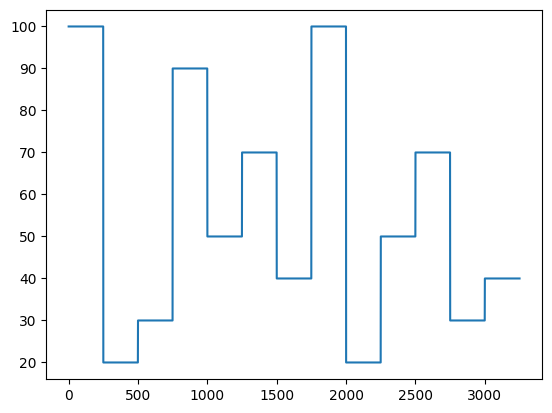

In [1349]:
plt.plot(u_train)


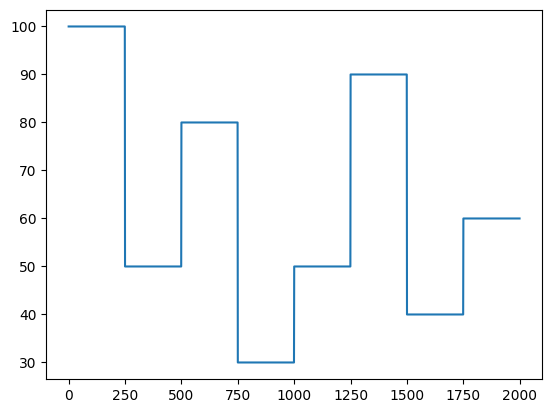

In [1350]:
plt.plot(u_test)

In [1351]:
""" data = loadmat('T50-d10-5m_T4.mat')
data['T4'][:,0] """

" data = loadmat('T50-d10-5m_T4.mat')\ndata['T4'][:,0] "

In [1352]:

train_data['Ytrain'][:,0]

array([60.55718475, 60.55718475, 60.41055718, ..., 53.66568915,
       53.51906158, 53.37243402])

In [1353]:
""" simx = len(data['T4']) - shift
x_train = np.zeros((simx*len(relevantx_train)))
for index, file in enumerate(sorted(relevantx_train)):
    data = loadmat(file)
    x_train[index*simx:index*simx+simx] = data['T4'][shift:,0]
    
with open('x_train.pkl', 'wb') as file:
    pickle.dump(x_train, file) """
    
x_train = train_data['Ytrain'][:,0]
x_train

array([60.55718475, 60.55718475, 60.41055718, ..., 53.66568915,
       53.51906158, 53.37243402])

In [1354]:
""" simx = len(data['T4']) - shift
x_test = np.zeros((simx*len(relevantx_test)))
for index, file in enumerate(sorted(relevantx_test)):
    data = loadmat(file)
    x_test[index*simx:index*simx+simx] = data['T4'][shift:,0]
    
with open('x_test.pkl', 'wb') as file:
    pickle.dump(x_test, file) """
    
x_test = test_data['Ytest'][:,0]
x_test 

array([57.3313783 , 57.62463343, 57.771261  , ..., 64.07624633,
       63.92961877, 64.2228739 ])

In [1355]:
x_train.reshape(-1,1)

array([[60.55718475],
       [60.55718475],
       [60.41055718],
       ...,
       [53.66568915],
       [53.51906158],
       [53.37243402]])

In [1356]:
train_real = {'Y': x_train.reshape(-1,1), 'U': u_train.reshape(-1,1)}
test_real = {'Y': x_test.reshape(-1,1), 'U': u_test.reshape(-1,1)}

with open('train_real.pkl', 'wb') as file:
    pickle.dump(train_real, file)
    
with open('test_real.pkl', 'wb') as file:
    pickle.dump(test_real, file)

In [1357]:
train_real = pickle.load(open('train_real.pkl', 'rb'))

test_real = pickle.load(open('test_real.pkl', 'rb'))
train_real


{'Y': array([[60.55718475],
        [60.55718475],
        [60.41055718],
        ...,
        [53.66568915],
        [53.51906158],
        [53.37243402]]),
 'U': array([[100],
        [100],
        [100],
        ...,
        [ 40],
        [ 40],
        [ 40]], dtype=uint8)}

In [1358]:
test_real

{'Y': array([[57.3313783 ],
        [57.62463343],
        [57.771261  ],
        ...,
        [64.07624633],
        [63.92961877],
        [64.2228739 ]]),
 'U': array([[100],
        [100],
        [100],
        ...,
        [ 60],
        [ 60],
        [ 60]], dtype=uint8)}

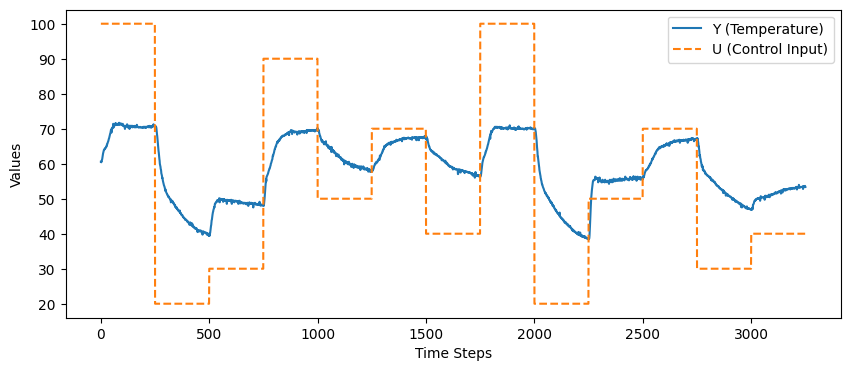

In [1359]:
""" plt.plot(train_real) """

plt.figure(figsize=(10,4))
plt.plot(x_train, label='Y (Temperature)')
plt.plot(u_train, label='U (Control Input)', linestyle='dashed')
plt.xlabel('Time Steps')
plt.ylabel('Values')
plt.legend()
plt.show()

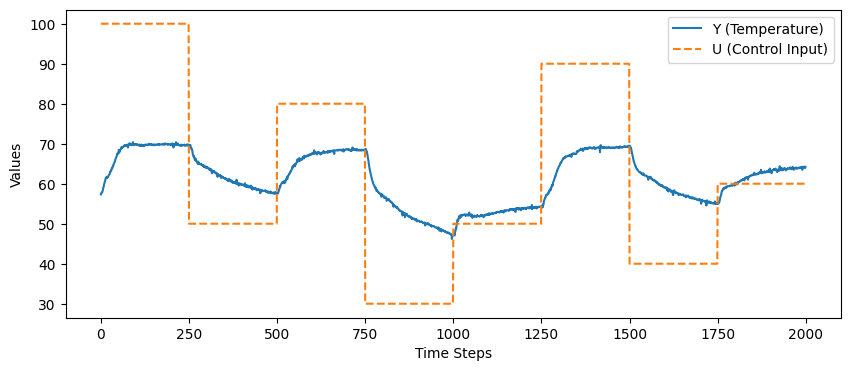

In [1360]:
plt.figure(figsize=(10,4))
plt.plot(x_test, label='Y (Temperature)')
plt.plot(u_test, label='U (Control Input)', linestyle='dashed')
plt.xlabel('Time Steps')
plt.ylabel('Values')
plt.legend()
plt.show()

In [1361]:
""" simx = len(data['T4']) - shift
x = np.zeros((simx*len(relevantx)))
for index, file in enumerate(sorted(relevantx)):
    data = loadmat(file)
    x[index*simx:index*simx+simx] = data['T4'][shift:,0]
     """


    

" simx = len(data['T4']) - shift\nx = np.zeros((simx*len(relevantx)))\nfor index, file in enumerate(sorted(relevantx)):\n    data = loadmat(file)\n    x[index*simx:index*simx+simx] = data['T4'][shift:,0]\n     "

In [1362]:
import numpy as np
import joblib

scaler = joblib.load("scaler.pkl")
scalerU = joblib.load("scalerU.pkl")

""" # Merge train and test data (test comes after train)
x = np.concatenate((x_train, x_test)).reshape(-1, 1)
u = np.concatenate((u_train, u_test)).reshape(-1, 1)

# Load scalers
scaler = joblib.load('scaler.pkl')
scalerU = joblib.load('scalerU.pkl')

# Scale signals
x = scaler.transform(x)
u = scalerU.transform(u)

# Initialize
step = 250
num_steps = len(x) // step
ident_data = np.zeros((int(len(x)/step), step))
dif = scalerU.transform(np.array([50]).reshape(-1, 1))


for i in range(0, len(x) - step + 1, step):
    delta_u = u[i + 100] - dif
    if delta_u == 0:
        continue  # avoid divide-by-zero
    normx = (x[i:i + step] - x[i]) / delta_u
    ident_data[i // step] = normx.flatten()
    print(f"Step {i // step}: Δu = {delta_u.flatten()[0]}")
    dif = u[i + 100] """

    
""" # Normalize segments
for i in range(0, x.shape[0] - step, step):
    delta_u = u[i+100] - dif  # Use value 100 samples into the step
    if delta_u == 0:
        continue  # Skip if no step change to avoid divide-by-zero

    normx = (x[i:i+step] - x[i]) / delta_u
    ident_data[i // step] = normx.flatten()

    print(f"Step {i//step}: Δu = {(u[i+100] - dif).flatten()[0]}")
    dif = u[i+100]  # Update reference for next step """


' # Normalize segments\nfor i in range(0, x.shape[0] - step, step):\n    delta_u = u[i+100] - dif  # Use value 100 samples into the step\n    if delta_u == 0:\n        continue  # Skip if no step change to avoid divide-by-zero\n\n    normx = (x[i:i+step] - x[i]) / delta_u\n    ident_data[i // step] = normx.flatten()\n\n    print(f"Step {i//step}: Δu = {(u[i+100] - dif).flatten()[0]}")\n    dif = u[i+100]  # Update reference for next step '

In [1363]:
def extract_normalized_steps(u_raw, x_raw, step_size=250, delay=100, threshold=0.01, initial_ref=50, label=""):
    u_scaled = scalerU.transform(u_raw.reshape(-1, 1))
    x_scaled = scaler.transform(x_raw.reshape(-1, 1))

    delta_u = np.diff(u_scaled.flatten(), prepend=u_scaled[0])
    step_starts = np.where(np.abs(delta_u) > threshold)[0]

    if step_starts[0] == 0:
        step_starts = step_starts[1:]

    ident_data = []
    step_info = []
    dif = scalerU.transform(np.array([[initial_ref]]))  # reset for each call

    print(f"\n--- {label.upper()} STEP INFO ---")
    for idx in step_starts:
        if idx + step_size > len(u_scaled):
            print(f"Skipping step at t = {idx}: not enough samples for full step window.")
            continue

        delta = u_scaled[idx + delay] - dif
        if delta == 0:
            continue

        normx = (x_scaled[idx:idx + step_size] - x_scaled[idx]) / delta
        ident_data.append(normx.flatten())

        u_unscaled_before = scalerU.inverse_transform(dif.reshape(1, -1)).flatten()[0]
        u_unscaled_after = scalerU.inverse_transform(u_scaled[idx + delay].reshape(1, -1)).flatten()[0]
        delta_unscaled = u_unscaled_after - u_unscaled_before

        print(f"Step at t = {idx}: u changed from {u_unscaled_before:.1f} to {u_unscaled_after:.1f} (Δu = {delta_unscaled:.1f})")

        step_info.append({
            "index": idx,
            "u_before": u_unscaled_before,
            "u_after": u_unscaled_after,
            "delta_u": delta_unscaled
        })

        dif = u_scaled[idx + delay]

    return np.array(ident_data), step_starts, step_info



In [1364]:
train_steps, train_indices, train_info = extract_normalized_steps(
    u_train, x_train, step_size=250, label="train", initial_ref=u_train[0]
)

test_steps, test_indices, test_info = extract_normalized_steps(
    u_test, x_test, step_size=250, label="test", initial_ref=u_test[0]
)
# Combine if needed
all_ident_data = np.vstack((train_steps, test_steps))


--- TRAIN STEP INFO ---
Step at t = 250: u changed from 100.0 to 20.0 (Δu = -80.0)
Step at t = 500: u changed from 20.0 to 30.0 (Δu = 10.0)
Step at t = 750: u changed from 30.0 to 90.0 (Δu = 60.0)
Step at t = 1000: u changed from 90.0 to 50.0 (Δu = -40.0)
Step at t = 1250: u changed from 50.0 to 70.0 (Δu = 20.0)
Step at t = 1500: u changed from 70.0 to 40.0 (Δu = -30.0)
Step at t = 1750: u changed from 40.0 to 100.0 (Δu = 60.0)
Step at t = 2000: u changed from 100.0 to 20.0 (Δu = -80.0)
Step at t = 2250: u changed from 20.0 to 50.0 (Δu = 30.0)
Step at t = 2500: u changed from 50.0 to 70.0 (Δu = 20.0)
Step at t = 2750: u changed from 70.0 to 30.0 (Δu = -40.0)
Step at t = 3000: u changed from 30.0 to 40.0 (Δu = 10.0)

--- TEST STEP INFO ---
Step at t = 250: u changed from 100.0 to 50.0 (Δu = -50.0)
Step at t = 500: u changed from 50.0 to 80.0 (Δu = 30.0)
Step at t = 750: u changed from 80.0 to 30.0 (Δu = -50.0)
Step at t = 1000: u changed from 30.0 to 50.0 (Δu = 20.0)
Step at t = 1250: 

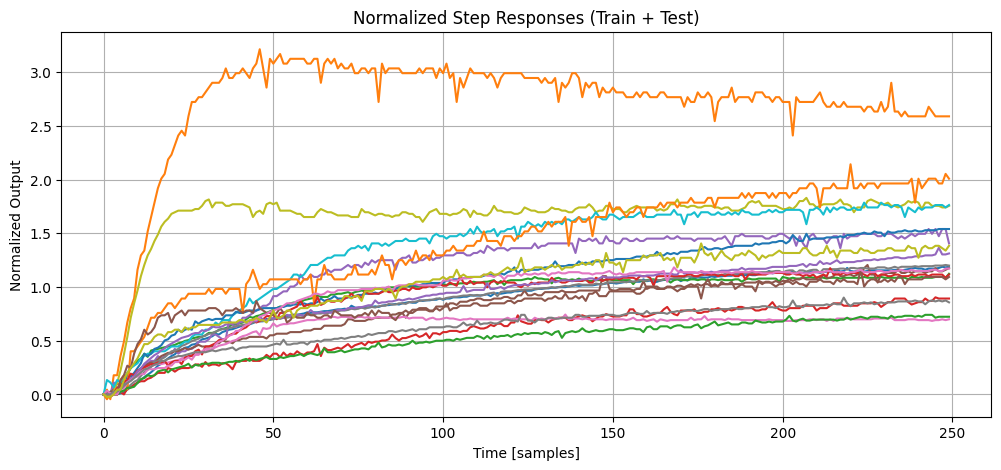

Total valid steps: 19


In [1365]:
plt.figure(figsize=(12, 5))
for row in all_ident_data:
    plt.plot(row)
plt.title('Normalized Step Responses (Train + Test)')
plt.xlabel('Time [samples]')
plt.ylabel('Normalized Output')
plt.grid(True)
plt.show()

print(f"Total valid steps: {all_ident_data.shape[0]}")


In [1366]:
dif


array([0.17282704])

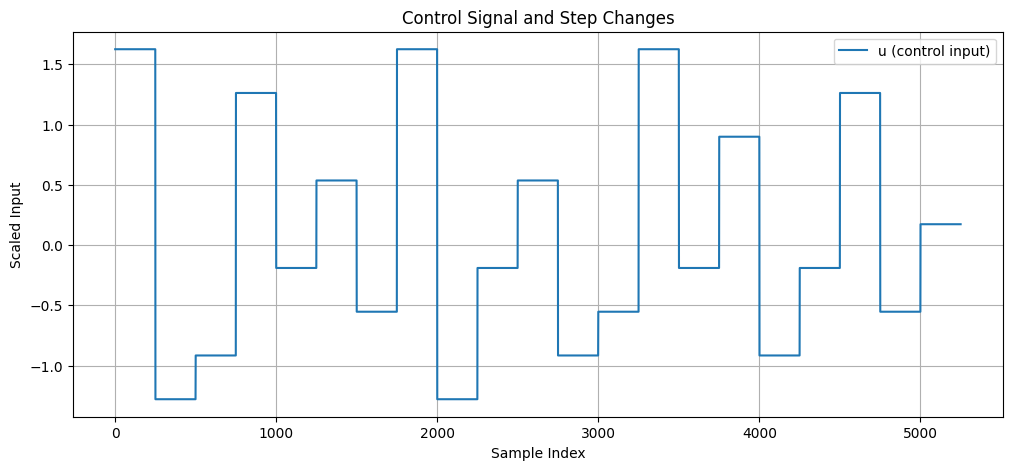

In [1367]:
# Plot control signal and its difference
u_flat = u.flatten()
delta_u = np.diff(u_flat, prepend=u_flat[0])

plt.figure(figsize=(12, 5))
plt.plot(u_flat, label='u (control input)')
""" plt.plot(delta_u, label='Δu (difference)', linestyle='dashed') """
plt.title('Control Signal and Step Changes')
plt.xlabel('Sample Index')
plt.ylabel('Scaled Input')
plt.grid(True)
plt.legend()
plt.show()

In [1368]:
""" data = loadmat('u50-d10-5m.mat') """

" data = loadmat('u50-d10-5m.mat') "

In [1369]:
""" simu = len(data['uout']) - shift
u = np.zeros((simu*len(relevantu)))
for index, file in enumerate(sorted(relevantu)):
    data = loadmat(file)
    print(data['uout'][shift:,0].shape)
    u[index*simu:index*simu+simu] = data['uout'][shift:,1]
     """

" simu = len(data['uout']) - shift\nu = np.zeros((simu*len(relevantu)))\nfor index, file in enumerate(sorted(relevantu)):\n    data = loadmat(file)\n    print(data['uout'][shift:,0].shape)\n    u[index*simu:index*simu+simu] = data['uout'][shift:,1]\n     "

In [1370]:
""" plt.plot(x[1500:4000]) """

' plt.plot(x[1500:4000]) '

In [1371]:
np.zeros((3,2))

array([[0., 0.],
       [0., 0.],
       [0., 0.]])

In [1387]:
len(x_train)/250

13.004

In [1373]:
u

array([[1.62499574],
       [1.62499574],
       [1.62499574],
       ...,
       [0.17282704],
       [0.17282704],
       [0.17282704]])

In [1374]:
""" import joblib

scaler = joblib.load('scaler.pkl')
scalerU = joblib.load('scalerU.pkl')
x = scaler.transform(x.reshape(-1,1))
u = scalerU.transform(u.reshape(-1,1))
dif = scalerU.transform(np.array([50]).reshape(-1,1)) """

" import joblib\n\nscaler = joblib.load('scaler.pkl')\nscalerU = joblib.load('scalerU.pkl')\nx = scaler.transform(x.reshape(-1,1))\nu = scalerU.transform(u.reshape(-1,1))\ndif = scalerU.transform(np.array([50]).reshape(-1,1)) "

In [1375]:
u

array([[1.62499574],
       [1.62499574],
       [1.62499574],
       ...,
       [0.17282704],
       [0.17282704],
       [0.17282704]])

In [1376]:
int(len(x)/250)



21

In [1377]:
int(len(u)/250)

21

In [1378]:
""" ident_data = np.zeros((int(len(x)/250),250))


for i in range(0,len(x)-3, 250):
    normx = (x[i:i+250] - x[i]) / (u[i+100] - dif)
    ident_data[i//250] = normx.flatten()
    print(dif - u[i+100])
    dif = u[i+100] """

' ident_data = np.zeros((int(len(x)/250),250))\n\n\nfor i in range(0,len(x)-3, 250):\n    normx = (x[i:i+250] - x[i]) / (u[i+100] - dif)\n    ident_data[i//250] = normx.flatten()\n    print(dif - u[i+100])\n    dif = u[i+100] '

In [1391]:
all_ident_data.shape
all_ident_data

array([[-0.        , -0.        , -0.        , ...,  1.18893328,
         1.18335143,  1.18893328],
       [ 0.        ,  0.04465477, -0.04465477, ...,  2.58997672,
         2.58997672,  2.58997672],
       [ 0.        , -0.00744246,  0.        , ...,  1.09404189,
         1.08659943,  1.12381174],
       ...,
       [ 0.        ,  0.03349108,  0.01116369, ...,  1.14986036,
         1.17218774,  1.17218774],
       [-0.        , -0.        , -0.        , ...,  0.86630256,
         0.87523351,  0.8573716 ],
       [ 0.        , -0.02232739, -0.02232739, ...,  1.36197052,
         1.33964313,  1.3842979 ]])

In [1380]:
""" plt.figure(figsize=(10, 6))
for row in ident_data:
    plt.plot(row)

plt.xlabel('Index')
plt.ylabel('Value')
plt.title('Plot of 24 Lines from np.array')
plt.show() """

" plt.figure(figsize=(10, 6))\nfor row in ident_data:\n    plt.plot(row)\n\nplt.xlabel('Index')\nplt.ylabel('Value')\nplt.title('Plot of 24 Lines from np.array')\nplt.show() "

Steady-state gain K ≈ 1.3130
Time constant (τ) ≈ 43 samples


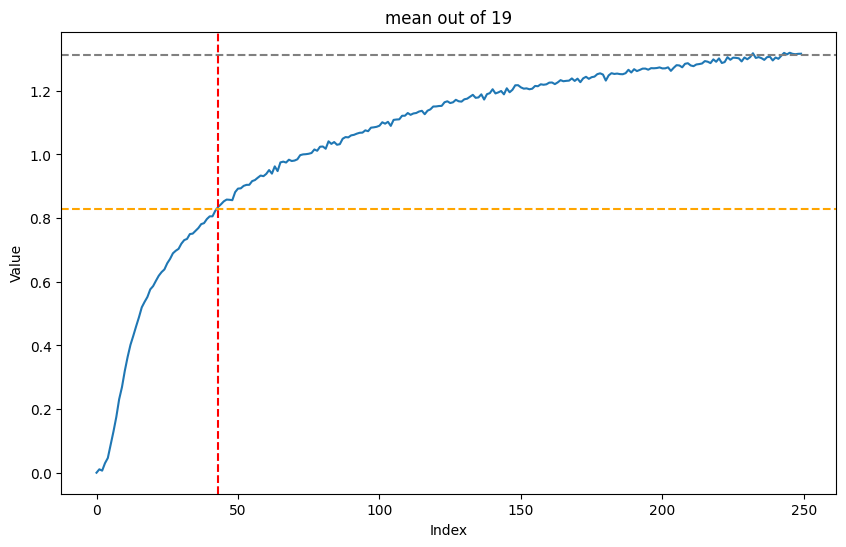

In [1381]:
mean_row = np.mean(all_ident_data, axis=0)
K = np.mean(mean_row[-10:])
target_value = 0.632 * K

#time constant idx
time_constant_idx = np.where(mean_row >= target_value)[0][0]


print(f"Steady-state gain K ≈ {K:.4f}")
print(f"Time constant (τ) ≈ {time_constant_idx} samples")


plt.figure(figsize=(10, 6))

plt.plot(mean_row)
plt.axhline(K, linestyle='--', color='gray', label='Steady State K')
plt.axhline(target_value, linestyle='--', color='orange', label='63.2% of K')
plt.axvline(time_constant_idx, linestyle='--', color='red', label='τ')

plt.xlabel('Index')
plt.ylabel('Value')
plt.title('mean out of 19')
plt.show()

In [1389]:
print("Python scaler mean (x):", scaler.mean_[0])
print("Python scaler std (x):", scaler.scale_[0])

print("Python scaler mean (u):", scalerU.mean_[0])
print("Python scaler std (u):", scalerU.scale_[0])


Python scaler mean (x): 58.3152397953799
Python scaler std (x): 9.07091605268945
Python scaler mean (u): 54.61088895724392
Python scaler std (u): 27.625070163666503


In [1390]:
print("x_scaled mean:", np.mean(x_scaled))
print("x_scaled std:", np.std(x_scaled))

print("u_scaled mean:", np.mean(u_scaled))
print("u_scaled std:", np.std(u_scaled))


NameError: name 'x_scaled' is not defined

In [1382]:
""" K = np.mean(mean_row[-10:])
target_value = 0.632 * K
time_constant_idx = np.where(mean_row >= target_value)[0][0] if np.any(mean_row >= target_value) else None
 """

' K = np.mean(mean_row[-10:])\ntarget_value = 0.632 * K\ntime_constant_idx = np.where(mean_row >= target_value)[0][0] if np.any(mean_row >= target_value) else None\n '

In [1383]:
""" shift = 300

u_train = np.zeros((simu*len(relevantu)))
for index, file in enumerate(sorted(relevantu)):
    data = loadmat(file)
    u_train[index*simu:index*simu+simu] = data['uout'][shift:,1]

with open('u_train.pkl', 'wb') as file: 
    pickle.dump(u_train, file) """

" shift = 300\n\nu_train = np.zeros((simu*len(relevantu)))\nfor index, file in enumerate(sorted(relevantu)):\n    data = loadmat(file)\n    u_train[index*simu:index*simu+simu] = data['uout'][shift:,1]\n\nwith open('u_train.pkl', 'wb') as file: \n    pickle.dump(u_train, file) "

In [1384]:
""" x_train = np.zeros((simx*len(relevantx)))
for index, file in enumerate(sorted(relevantx)):
    data = loadmat(file)
    x_train[index*simx:index*simx+simx] = data['T4'][shift:,0]
    
with open('x_train.pkl', 'wb') as file:
    pickle.dump(x_train, file)
     """

" x_train = np.zeros((simx*len(relevantx)))\nfor index, file in enumerate(sorted(relevantx)):\n    data = loadmat(file)\n    x_train[index*simx:index*simx+simx] = data['T4'][shift:,0]\n\nwith open('x_train.pkl', 'wb') as file:\n    pickle.dump(x_train, file)\n     "

In [1385]:
""" len(x_train) """

' len(x_train) '

In [1386]:
""" train_real = {'Y': x_train.reshape(-1,1), 'U': u_train.reshape(-1,1)}
test_real = {'Y': x_train.reshape(-1,1), 'U': u_train.reshape(-1,1)}

with open('train_real.pkl', 'wb') as file:
    pickle.dump(train_real, file)
    
with open('test_real.pkl', 'wb') as file:
    pickle.dump(test_real, file) """

" train_real = {'Y': x_train.reshape(-1,1), 'U': u_train.reshape(-1,1)}\ntest_real = {'Y': x_train.reshape(-1,1), 'U': u_train.reshape(-1,1)}\n\nwith open('train_real.pkl', 'wb') as file:\n    pickle.dump(train_real, file)\n\nwith open('test_real.pkl', 'wb') as file:\n    pickle.dump(test_real, file) "